Checking the XML path and reading from it

In [2]:
import xml.etree.ElementTree as ET
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path
import xml.etree.ElementTree as ET

XML_PATH = Path("data/landmarks/landmarks_P001_P030/annotations.xml")

print("Exists:", XML_PATH.exists())
print("Path:", XML_PATH.resolve())

Exists: True
Path: C:\Users\Asus\Desktop\Files\EyeDerivationProject\data\landmarks\landmarks_P001_P030\annotations.xml


In [4]:
tree = ET.parse(XML_PATH)
root = tree.getroot()

print("Root tag:", root.tag)
print("Root attributes:", root.attrib)

images = root.findall(".//image")

print("Number of images:", len(images))

Root tag: annotations
Root attributes: {}
Number of images: 30


Exporting landmarks from XML

In [5]:
landmark_labels = [
    "left_eye_inner_corner",
    "left_eye_outer_corner",
    "left_white_point",
    "right_eye_inner_corner",
    "right_eye_outer_corner",
    "right_white_point",
]

landmarks = {}

for image in images:
    image_name = image.attrib["name"]

    landmarks[image_name] = {}

    for point in image.findall("points"):
        label = point.attrib["label"]

        if label in landmark_labels:
            x, y = map(float, point.attrib["points"].split(","))

            landmarks[image_name][label] = (x, y)

print("Number of images:", len(landmarks))
print(landmarks[list(landmarks.keys())[0]])

Number of images: 30
{'right_white_point': (1251.2, 1848.1), 'left_white_point': (1687.9, 1847.3), 'right_eye_outer_corner': (1120.5, 1870.1), 'right_eye_inner_corner': (1345.1, 1881.1), 'left_eye_outer_corner': (1794.69, 1871.75), 'left_eye_inner_corner': (1582.79, 1880.15)}


In [6]:
for image_name, points in landmarks.items():
    missing = [
        label
        for label in landmark_labels
        if label not in points
    ]

    if missing:
        print(image_name, "missing:", missing)

In [7]:
from collections import Counter

counts = Counter(
    len(points)
    for points in landmarks.values()
)

print(counts)

Counter({6: 30})


Checking the points coordinates on photos

In [8]:
IMAGE_DIR = Path("data/selected_photos")

first_image = list(landmarks.keys())[0]

print("Image name:", first_image)
print("Image exists:", (IMAGE_DIR / first_image).exists())

Image name: P001_IMG_7116.JPG
Image exists: True


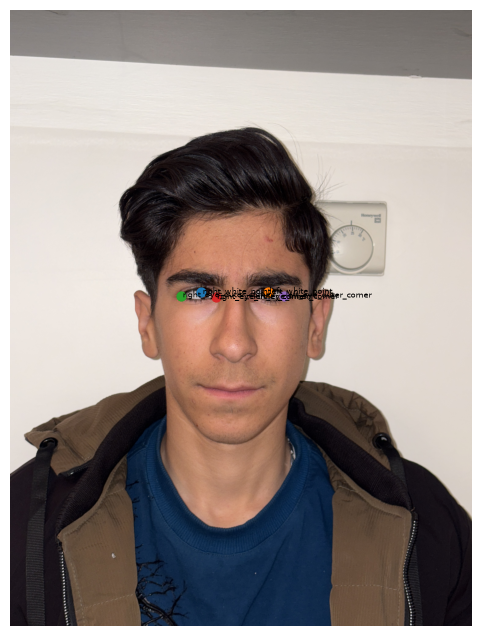

In [22]:
import cv2
import matplotlib.pyplot as plt

img_path = IMAGE_DIR / first_image

img = cv2.imread(str(img_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img)

for label, (x, y) in landmarks[first_image].items():
    plt.scatter(x, y, s=40)
    plt.text(
        x + 10,
        y + 10,
        label,
        fontsize=6
    )

plt.axis("off")
plt.show()

Exporting iris polygons

In [10]:
iris_labels = [
    "left_iris_mask",
    "right_iris_mask"
]

iris_masks = {}

for image in images:
    image_name = image.attrib["name"]
    iris_masks[image_name] = {}

    for polygon in image.findall("polygon"):
        label = polygon.attrib["label"]

        if label in iris_labels:
            points_str = polygon.attrib["points"]

            points = []
            for p in points_str.split(";"):
                x, y = map(float, p.split(","))
                points.append((x, y))

            iris_masks[image_name][label] = points

print(iris_masks[first_image])

{'left_iris_mask': [(1646.84, 1832.26), (1644.7, 1850.6), (1651.1, 1867.9), (1669.5, 1883.0), (1698.7, 1887.9), (1720.2, 1879.4), (1733.3, 1862.1), (1734.32, 1841.22)], 'right_iris_mask': [(1221.4, 1838.1), (1224.0, 1858.4), (1236.5, 1876.7), (1255.1, 1886.8), (1285.0, 1884.8), (1302.7, 1869.9), (1309.73, 1852.61), (1309.73, 1838.96)]}


In [11]:
for image_name, masks in iris_masks.items():
    missing = [
        label
        for label in iris_labels
        if label not in masks
    ]

    if missing:
        print(image_name, "missing:", missing)

In [12]:
from collections import Counter

mask_counts = Counter(
    len(masks)
    for masks in iris_masks.values()
)

print(mask_counts)

Counter({2: 30})


Creating bounding box

In [16]:
left_keypoints = [
    "left_eye_inner_corner",
    "left_eye_outer_corner",
    "left_white_point"
]
left_iris = "left_iris_mask"

right_keypoints = [
    "right_eye_inner_corner",
    "right_eye_outer_corner",
    "right_white_point"
]
right_iris = "right_iris_mask"

In [17]:
def create_eye_bbox(
    landmarks_dict,
    iris_dict,
    keypoint_labels,
    iris_label,
    padding_ratio=0.15
):
    """
    Create an eye bounding box from:
    - 3 eye landmarks
    - iris polygon
    """

    # Landmark coordinates
    points = [
        landmarks_dict[label]
        for label in keypoint_labels
    ]

    # Iris polygon coordinates
    points.extend(iris_dict[iris_label])

    points = np.array(points, dtype=np.float32)

    x_min = points[:, 0].min()
    x_max = points[:, 0].max()

    y_min = points[:, 1].min()
    y_max = points[:, 1].max()

    width = x_max - x_min
    height = y_max - y_min

    # Add padding
    x_padding = width * padding_ratio
    y_padding = height * padding_ratio

    x_min -= x_padding
    x_max += x_padding
    y_min -= y_padding
    y_max += y_padding

    return [
        x_min,
        y_min,
        x_max,
        y_max
    ]

In [18]:
left_bbox = create_eye_bbox(
    landmarks[first_image],
    iris_masks[first_image],
    left_keypoints,
    "left_iris_mask"
)

right_bbox = create_eye_bbox(
    landmarks[first_image],
    iris_masks[first_image],
    right_keypoints,
    "right_iris_mask"
)

print("Left bbox:", left_bbox)
print("Right bbox:", right_bbox)

Left bbox: [np.float32(1551.005), np.float32(1823.9141), np.float32(1826.475), np.float32(1896.246)]
Right bbox: [np.float32(1086.81), np.float32(1830.7949), np.float32(1378.7899), np.float32(1894.1051)]


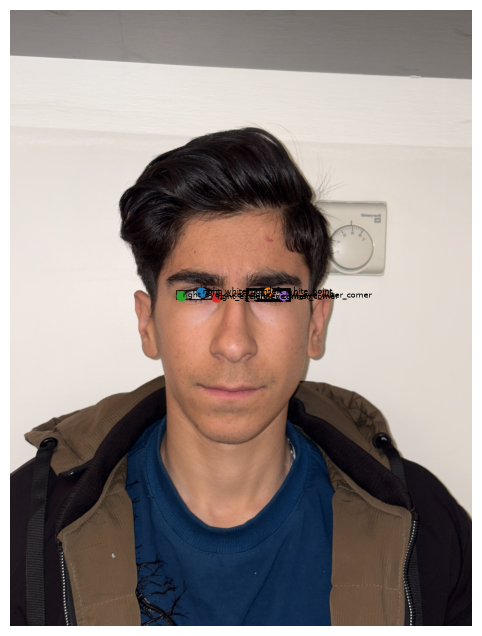

In [ ]:
img = cv2.imread(str(IMAGE_DIR / first_image))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img)

# Left eye bbox
x1, y1, x2, y2 = left_bbox

plt.gca().add_patch(
    plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=2
    )
)

# Right eye bbox
x1, y1, x2, y2 = right_bbox

plt.gca().add_patch(
    plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        linewidth=1
    )
)

# Plot landmarks
for label, (x, y) in landmarks[first_image].items():
    plt.scatter(x, y, s=40)
    plt.text(
        x + 10,
        y + 10,
        label,
        fontsize=6
    )

plt.axis("off")
plt.show()